## 1. Data Loading and Preprocessing
Build a modeling-ready dataset.
- 1.1 Load raw data from `final_merged_data.csv` into `df`.
- 1.2 Convert `last_reported` to datetime, then extract `hour` and `day_of_week`.
- 1.3 Define the regression target as `num_bikes_available`.
- 1.4 Select business-relevant features (station, time, month, weather) and keep `feature_cols + target`.
- 1.5 Remove missing values to create `df_clean`.

In [13]:
import pandas as pd

# 1) Read the dataset
df = pd.read_csv("final_merged_data.csv")

# 2) Process the time column: convert to datetime and extract hour and day_of_week
df["last_reported"] = pd.to_datetime(df["last_reported"], errors="coerce")
df["hour"] = df["last_reported"].dt.hour
df["day_of_week"] = df["last_reported"].dt.dayofweek

# 3) Define the target column for the regression task
target_col = "num_bikes_available"

# 4) Select only the specified features and the target column
feature_cols = [
    "station_id",
    "hour",
    "day_of_week",
    "month",
    "max_air_temperature_celsius",
    "max_relative_humidity_percent",
    "max_barometric_pressure_hpa",
]
keep_cols = feature_cols + [target_col]

df_selected = df[keep_cols].copy()

# 5) Remove rows with missing values in the selected columns
df_clean = df_selected.dropna()

# 6) Print an overview of the cleaned data
print("Cleaned data shape:", df_clean.shape)
print("\nFirst 5 rows:")
print(df_clean.head())

Cleaned data shape: (298946, 8)

First 5 rows:
   station_id  hour  day_of_week  month  max_air_temperature_celsius  \
0          10     0            6     12                        14.01   
1         100     0            6     12                        14.01   
2         109     0            6     12                        14.01   
3          11     0            6     12                        14.01   
4         114     0            6     12                        14.01   

   max_relative_humidity_percent  max_barometric_pressure_hpa  \
0                           84.3                      1002.56   
1                           84.3                      1002.56   
2                           84.3                      1002.56   
3                           84.3                      1002.56   
4                           84.3                      1002.56   

   num_bikes_available  
0                   15  
1                   17  
2                   20  
3                    1  
4   

## 2. Model Training and Performance Evaluation
Train and compare multiple regression models under a consistent workflow.
- 1.1 Build training inputs using `X = df_clean[feature_cols]` and `y = df_clean[target_col]`.
- 1.2 Split data into training and test sets with an 80/20 ratio (`random_state=42` for reproducibility).
- 1.3 Initialize four models: Linear Regression, Decision Tree, Random Forest, and KNN.
- 1.4 Train each model, generate predictions, and compute MAE, RMSE, and R2.
- 1.5 Aggregate outputs into `results_df`.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# 1) Split the features and target
X = df_clean[feature_cols]
y = df_clean[target_col]

# 2) Split the dataset into training and testing sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 3) Initialize the models, set limits
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree Regressor": DecisionTreeRegressor(
        max_depth=25,          
        min_samples_split=20, 
        min_samples_leaf=10,  
        random_state=42
    ),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=50,
        max_depth=25,
        min_samples_split=20,
        min_samples_leaf=10,
        n_jobs=-1,
        random_state=42,
    ),
    "KNeighbors Regressor": KNeighborsRegressor(),
}

# 4) Train and evaluate each model
results = []
for model_name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "Model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2,
    })

# 5) Summarize and display the results
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="MAE", ascending=True).reset_index(drop=True)
results_df["MAE"] = results_df["MAE"].round(4)
results_df["RMSE"] = results_df["RMSE"].round(4)
results_df["R2 Score"] = results_df["R2 Score"].round(4)

print("Model Evaluation on Test Set (sorted by MAE):")
display(results_df)

# 6) Print Random Forest metrics for quick regression quality check
rf_row = results_df.loc[results_df["Model"] == "Random Forest Regressor"].iloc[0]
print("\nCompressed Random Forest Metrics on Test Set:")
print(f"R2 Score: {rf_row['R2 Score']}")
print(f"MAE: {rf_row['MAE']}")
print(f"RMSE: {rf_row['RMSE']}")

Model Evaluation on Test Set (sorted by MAE):


,Model,MAE,RMSE,R2 Score
0,Random Forest Regressor,1.9903,3.0434,0.9021
1,Decision Tree Regressor,2.2121,3.8201,0.8458
2,KNeighbors Regressor,4.0336,5.8257,0.6414
3,Linear Regression,8.1363,9.7279,-0.0000



Compressed Random Forest Metrics on Test Set:
R2 Score: 0.9021
MAE: 1.9903
RMSE: 3.0434


## 3. Result Visualization
Visualize the metrics in `results_df` for direct model comparison.
- 1.1 Apply a unified `seaborn whitegrid` theme for readability.
- 1.2 Figure 1 compares MAE and RMSE using grouped bars (lower is better).
- 1.3 Figure 2 shows R2 scores (negative values clipped to 0, Y-axis fixed to 0-1; higher is better).

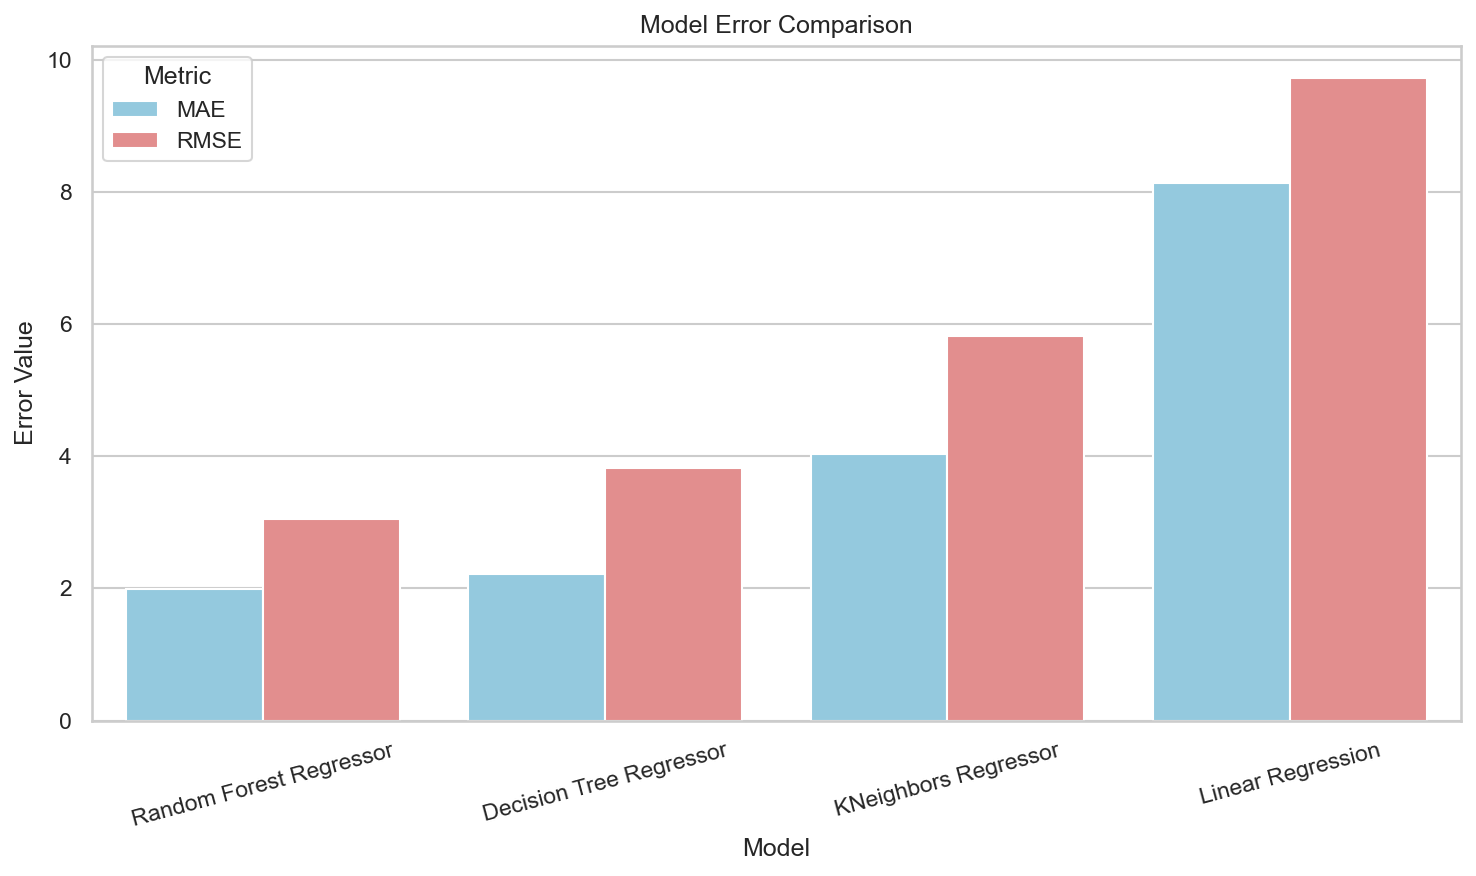

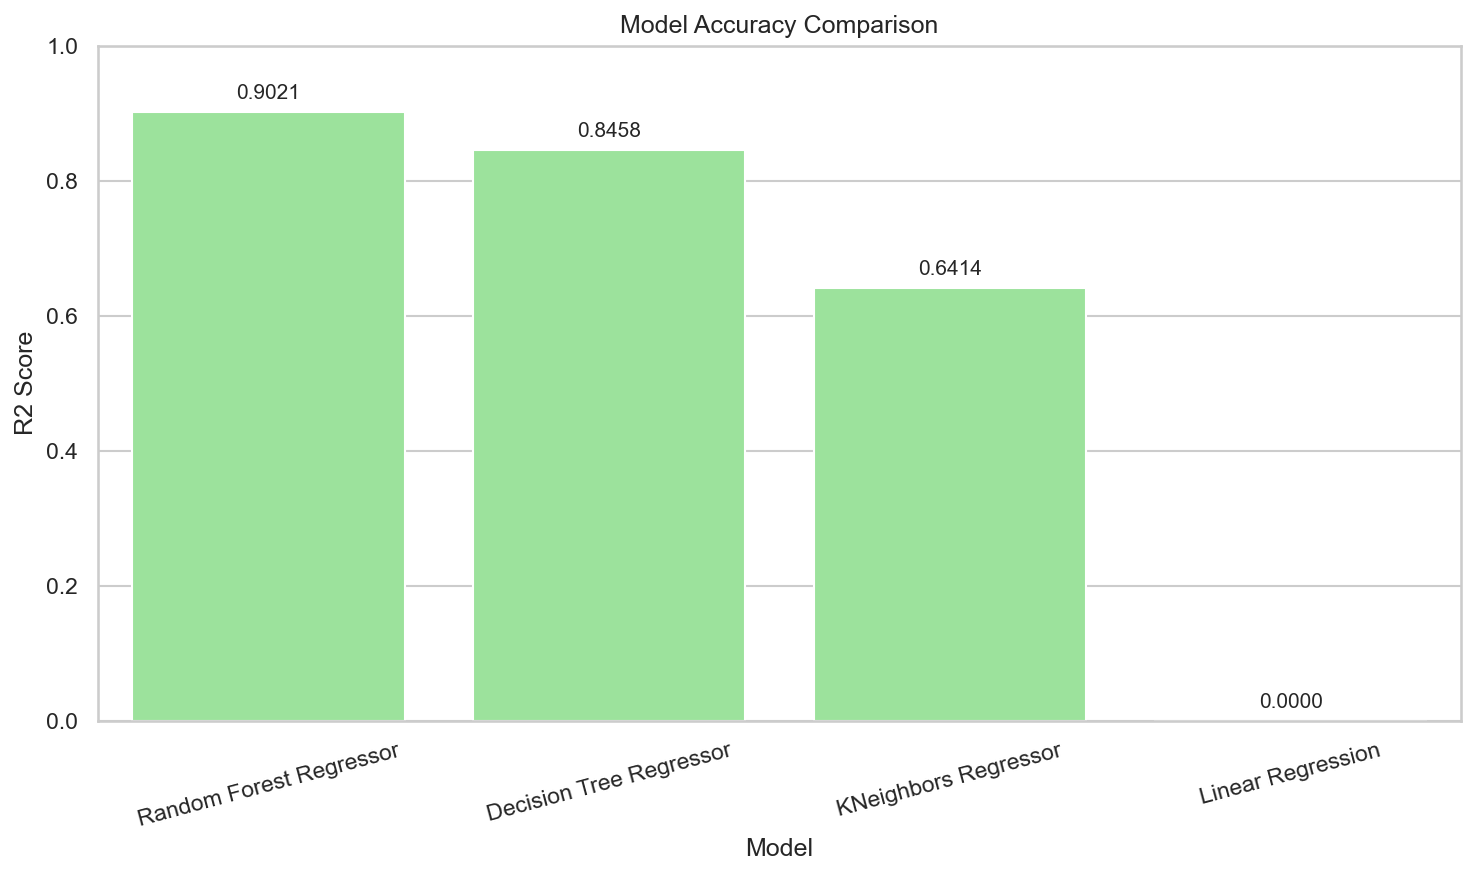

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Global style
sns.set_theme(style="whitegrid")

# Prepare long-form data for grouped bar chart (MAE vs RMSE)
error_df = results_df[["Model", "MAE", "RMSE"]].melt(
    id_vars="Model",
    value_vars=["MAE", "RMSE"],
    var_name="Metric",
    value_name="Value",
)

# Clip R2 to [0, 1] for display
r2_df = results_df[["Model", "R2 Score"]].copy()
r2_df["R2 Display"] = r2_df["R2 Score"].clip(lower=0, upper=1)

# Figure 1: MAE vs RMSE grouped bar chart
fig1, ax1 = plt.subplots(figsize=(10, 6), dpi=150)
sns.barplot(
    data=error_df,
    x="Model",
    y="Value",
    hue="Metric",
    hue_order=["MAE", "RMSE"],
    palette={"MAE": "skyblue", "RMSE": "lightcoral"},
    ax=ax1,
)
ax1.set_title("Model Error Comparison")
ax1.set_xlabel("Model")
ax1.set_ylabel("Error Value")
ax1.tick_params(axis="x", rotation=15)
fig1.tight_layout()
plt.show()

# Figure 2: R2 Score bar chart
fig2, ax2 = plt.subplots(figsize=(10, 6), dpi=150)
sns.barplot(
    data=r2_df,
    x="Model",
    y="R2 Display",
    color="lightgreen",
    ax=ax2,
)
ax2.set_title("Model Accuracy Comparison")
ax2.set_xlabel("Model")
ax2.set_ylabel("R2 Score")
ax2.set_ylim(0, 1)
ax2.tick_params(axis="x", rotation=15)

# Annotate R2 values on top of bars (4 decimals)
for p in ax2.patches:
    height = p.get_height()
    ax2.annotate(
        f"{height:.4f}",
        (p.get_x() + p.get_width() / 2, height),
        ha="center",
        va="bottom",
        fontsize=10,
        xytext=(0, 4),
        textcoords="offset points",
    )

fig2.tight_layout()
plt.show()

## 4. Best Model Selection
Identify and persist the best-performing model based on evaluation results.
- 1.1 Read the best model name from the first row of `results_df` (already sorted by minimum MAE).
- 1.2 Retrieve the final model object as `best_model` via `models[best_model_name]`.
- 1.3 Build the save path dynamically from the current working directory so it works across run locations.
- 1.4 Save a compressed model artifact with `joblib.dump(..., compress=3)`.

In [16]:
import joblib
from pathlib import Path

# Get the model with the highest score
best_model_name = results_df.iloc[0]["Model"]
print(f"\n The Best Model is: {best_model_name}")

best_model = models[best_model_name]

# Make save path robust to notebook working directory
cwd = Path.cwd()
if cwd.name == "ml":
    output_path = cwd / "best_bike_model.joblib"
else:
    output_path = cwd / "ml" / "best_bike_model.joblib"

output_path.parent.mkdir(parents=True, exist_ok=True)

# save the best model
joblib.dump(best_model, output_path, compress=3)

print(f"Compressed {best_model_name} model has been saved to {output_path}")


 The Best Model is: Random Forest Regressor
Compressed Random Forest Regressor model has been saved to /Users/flacko/Documents/ComputerScience/Project/comp30830/dublin-bikes-webapp/ml/best_bike_model.joblib


## 5. Random Forest Feature Importance Interpretation
Interpret how strongly `best_model` relies on each input feature.
- 1.1 Extract importance scores from `best_model.feature_importances_`.
- 1.2 Use `X.columns` as feature names to build the feature-importance mapping.
- 1.3 Sort by importance (descending) and draw a horizontal bar chart using the `viridis` palette.
- 1.4 Use the chart to quickly identify high-impact predictors.

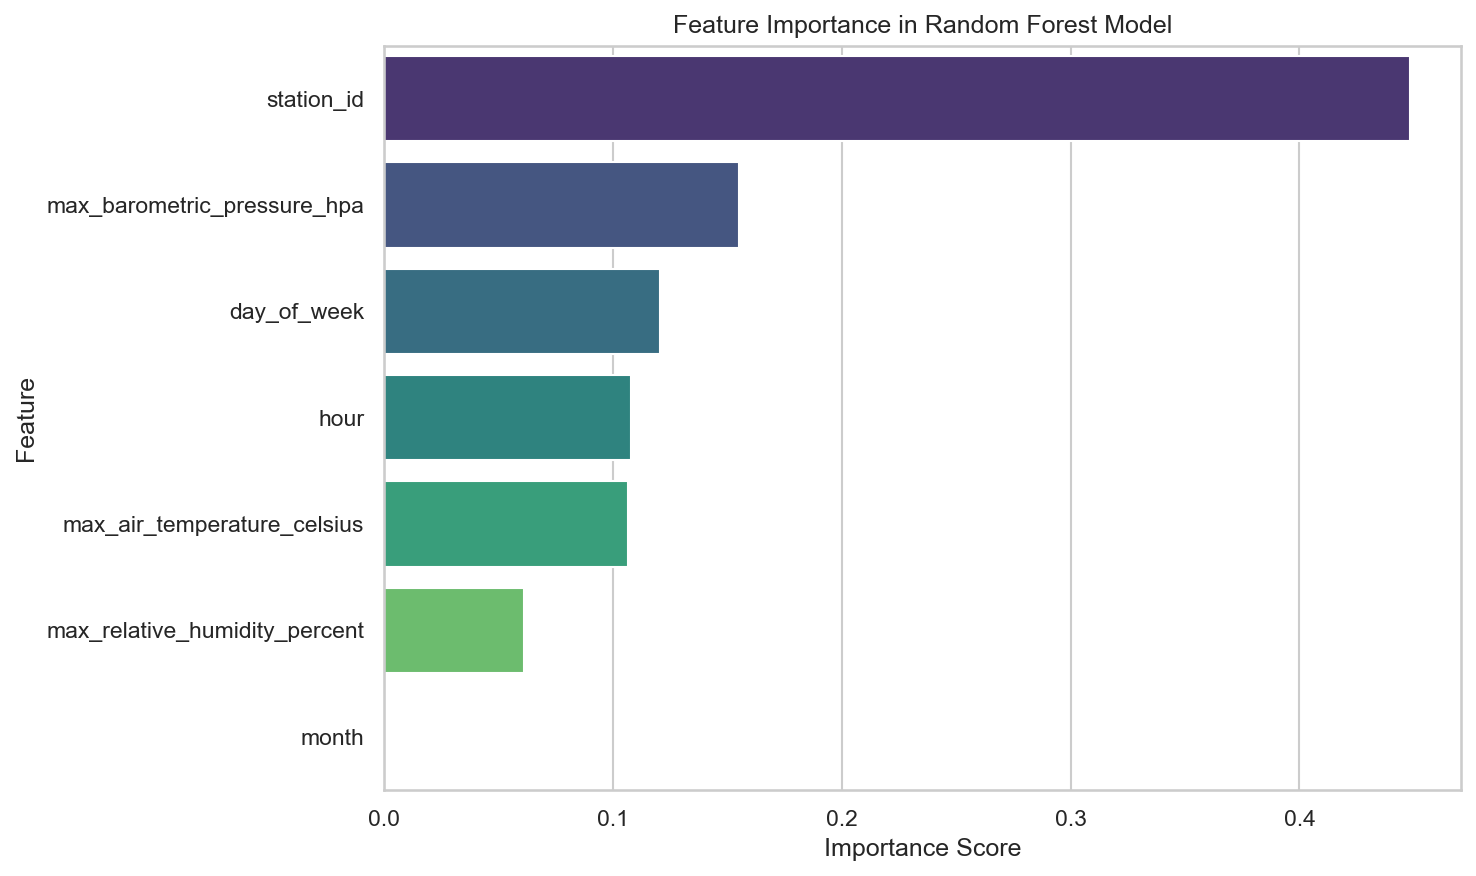

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# - Final model: best_model
# - Training feature dataset: X
importances = best_model.feature_importances_
feature_names = list(X.columns)

fi_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances,
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(10, 6), dpi=150)
sns.barplot(
    data=fi_df,
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False,
    dodge=False,
    orient="h",
)
plt.title("Feature Importance in Random Forest Model")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

## 6. Report on Model Compression and Cloud Deployment Optimization
1. Problem Statement
    - Our initial Random Forest model achieved high accuracy on the test set, but the exported model file (.joblib) was excessively large, reaching 468MB.
    
    - When deploying the full-stack web application to an AWS EC2 instance, we encountered fatal Out-of-Memory (OOM) crashes. The server was unable to load the model, rendering the web application inaccessible.

2. Root Cause Analysis
    - Extreme unconstrained tree growth within the Random Forest architecture.

    - Without explicit depth limits, the decision trees over-expanded to fit complex spatio-temporal data, essentially memorizing noise (a tendency toward overfitting).


3. Optimization Strategy
    - Algorithmic Pruning: We introduced strict regularization parameters to the tree-based models. By setting `max_depth=25, min_samples_split=20, and min_samples_leaf=10,` we restricted the trees from excessive splitting. 

    - Fair Benchmarking: To ensure an unbiased evaluation, identical pruning constraints were applied to the baseline Decision Tree.

    - I/O Compression: We utilized joblib's built-in compression (compress=3) during the serialization process, optimizing the disk footprint without sacrificing loading speed.

4. Results
    - The deployed model size : 468MB --> 21MB

    - the model maintained an good `R²` Score of 0.9021 and a `MAE` of 1.9903.